<h1>Predicción de tráfico</h1>

<h2>Carga de datos</h2> 

In [1]:
import pandas as pd
import numpy as np

'''
leemos el dataset `traffic.csv`
'''
df = pd.read_csv("traffic.csv")

'''
Pinto la informacion del dataset para ver cuantas entradas tiene el csv, 
que columnas tienen nulos y ver el tipo de dato que tiene cada columna
'''
print(df.info())
df


<class 'pandas.DataFrame'>
RangeIndex: 48120 entries, 0 to 48119
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   DateTime  48120 non-null  str  
 1   Junction  48120 non-null  int64
 2   Vehicles  48120 non-null  int64
 3   ID        48120 non-null  int64
dtypes: int64(3), str(1)
memory usage: 1.5 MB
None


,DateTime,Junction,Vehicles,ID
0,2015-11-01 00:00:00,1,15,20151101001
1,2015-11-01 01:00:00,1,13,20151101011
2,2015-11-01 02:00:00,1,10,20151101021
3,2015-11-01 03:00:00,1,7,20151101031
4,2015-11-01 04:00:00,1,9,20151101041
...,...,...,...,...
48115,2017-06-30 19:00:00,4,11,20170630194
48116,2017-06-30 20:00:00,4,30,20170630204
48117,2017-06-30 21:00:00,4,16,20170630214
48118,2017-06-30 22:00:00,4,22,20170630224


<h3>Comprobar duplicados en el dataset</h3>

In [2]:
# Comprobamos si el dataset tiene duplicados
num_duplicados = df.duplicated().sum()
print(f"Número de duplicados detectados: {num_duplicados}")

# Eliminamos duplicados solo si existen
if num_duplicados > 0:
    df.drop_duplicates(inplace=True)
    print("Duplicados eliminados correctamente.")
    print(f"Nuevo tamaño del dataset: {df.shape}")
else:
    print("No se encontraron duplicados. El dataset está limpio.")

Número de duplicados detectados: 0
No se encontraron duplicados. El dataset está limpio.


<h2>Preprocesado</h2>

In [3]:

'''
Convertir columna DateTime a datetime
'''
df['DateTime'] = pd.to_datetime(df['DateTime'])

'''
Agregar 3 nuevas columnas al dataframe:

    - Hour
    - DayOfWeek
    - Month
'''
df['Hour'] = df['DateTime'].dt.hour
df['DayOfWeek'] = df['DateTime'].dt.dayofweek
df['Month'] = df['DateTime'].dt.month

'''
Agregar una nueva columna para ver si es fin de semana (5:sabado, 6:domingo)

astype(int): convierte true o false en 1 o 0 respectivamente
'''
df['IsWeekend'] = (df['DayOfWeek'] >= 5).astype(int)

#informacion del dataframe
print(df.info())
df

<class 'pandas.DataFrame'>
RangeIndex: 48120 entries, 0 to 48119
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   DateTime   48120 non-null  datetime64[us]
 1   Junction   48120 non-null  int64         
 2   Vehicles   48120 non-null  int64         
 3   ID         48120 non-null  int64         
 4   Hour       48120 non-null  int32         
 5   DayOfWeek  48120 non-null  int32         
 6   Month      48120 non-null  int32         
 7   IsWeekend  48120 non-null  int64         
dtypes: datetime64[us](1), int32(3), int64(4)
memory usage: 2.4 MB
None


,DateTime,Junction,Vehicles,ID,Hour,DayOfWeek,Month,IsWeekend
0,2015-11-01 00:00:00,1,15,20151101001,0,6,11,1
1,2015-11-01 01:00:00,1,13,20151101011,1,6,11,1
2,2015-11-01 02:00:00,1,10,20151101021,2,6,11,1
3,2015-11-01 03:00:00,1,7,20151101031,3,6,11,1
4,2015-11-01 04:00:00,1,9,20151101041,4,6,11,1
...,...,...,...,...,...,...,...,...
48115,2017-06-30 19:00:00,4,11,20170630194,19,4,6,0
48116,2017-06-30 20:00:00,4,30,20170630204,20,4,6,0
48117,2017-06-30 21:00:00,4,16,20170630214,21,4,6,0
48118,2017-06-30 22:00:00,4,22,20170630224,22,4,6,0


In [4]:
'''
Ahora, sobran columnas:

    - ID sobra porque no le aporta ninguna info al modelo saber que una fila es la numero X
    - DateTime sobra porque ya extrajimos todo lo util de ella en las columnas:
        - Hour
        - DayOfWeek
        - Month
'''
#eliminamos  la columna DateTime + ID del dataframe
df.drop(["DateTime", "ID"], axis=1, inplace=True)
df

,Junction,Vehicles,Hour,DayOfWeek,Month,IsWeekend
0,1,15,0,6,11,1
1,1,13,1,6,11,1
2,1,10,2,6,11,1
3,1,7,3,6,11,1
4,1,9,4,6,11,1
...,...,...,...,...,...,...
48115,4,11,19,4,6,0
48116,4,30,20,4,6,0
48117,4,16,21,4,6,0
48118,4,22,22,4,6,0


<h2>Detección y eliminación de elementos outliers</h2>

Outliers
 1    46195
-1     1925
Name: count, dtype: int64


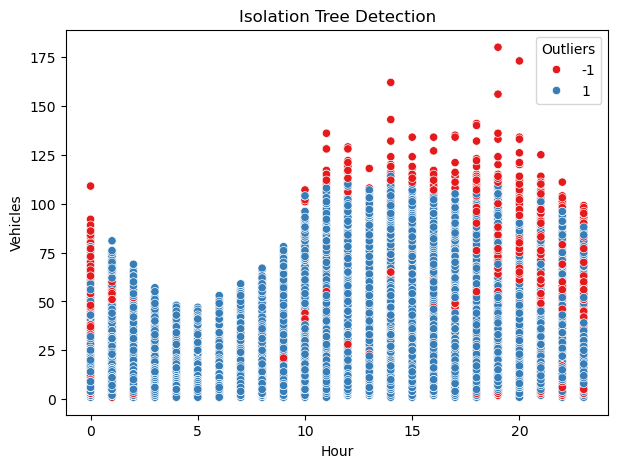

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest

iso = IsolationForest(contamination=0.04, random_state=1234)
y_pred_iso = iso.fit_predict(df)

df["Outliers"] = y_pred_iso
print(df["Outliers"].value_counts())

from sklearn.neighbors import LocalOutlierFactor

'''raiz = int(np.round(np.sqrt(df.shape[0]))) # Usada para la K en el KNN de LOF
print('Raiz: ' + str(raiz))
lof = LocalOutlierFactor(n_neighbors=raiz, contamination=0.04)
y_pred_lof = lof.fit_predict(df)

df["Outliers"] = y_pred_lof
print(df["Outliers"].value_counts())'''

'''cols = ['Junction', 'Vehicles']

Q1 = df[cols].quantile(0.25)
Q3 = df[cols].quantile(0.75)
IQR = Q3 - Q1

df = df[~((df[cols] < (Q1 - 1.5 * IQR)) |(df[cols] > (Q3 + 1.5 * IQR))).any(axis=1)]'''


plt.figure(figsize=(7, 5))
sns.scatterplot(x="Hour", y="Vehicles", data=df,
                hue="Outliers", palette='Set1')
plt.title("Isolation Tree Detection")
plt.show()

In [6]:
outliers = df.loc[df['Outliers'] == -1].index
df.drop(outliers, inplace=True)
df.drop(['Outliers'], axis=1, inplace=True)
df

,Junction,Vehicles,Hour,DayOfWeek,Month,IsWeekend
1,1,13,1,6,11,1
2,1,10,2,6,11,1
3,1,7,3,6,11,1
4,1,9,4,6,11,1
5,1,6,5,6,11,1
...,...,...,...,...,...,...
48115,4,11,19,4,6,0
48116,4,30,20,4,6,0
48117,4,16,21,4,6,0
48118,4,22,22,4,6,0


<h2>Aplicación de OneHotEncoding</h2>

In [7]:
'''
Cuando trabajamos con variables categóricas, una de las cuestiones más importantes es transformar nuestras variables categóricas en numéricas.
Para ello, aplicamos one-hot encoding, la cual consiste en crear tantas nuevas variables menos una como opciones tiene la variable y darle valor de 1 o 0. 
Si nos encontramos con datos de este tipo, debemos hacer la trasformación.

En este caso, nosotros deberemos implementar el One-Hot-Encoding sobre la columna Junction
'''
#importamos OneHotEncoder
from sklearn.preprocessing import OneHotEncoder

#Creamos el encoder
oneHotEncoder = OneHotEncoder(drop='first');

#Fit the encoder
oneHotEncoderFit = oneHotEncoder.fit(df['Junction'].values.reshape(-1,1))

#Trasformar los datos
junction_encoded = oneHotEncoderFit.transform(df['Junction'].values.reshape(-1,1)).toarray()

#Agregamos 3 nuevas columnas
df[['Junction_2', 'Junction_3', 'Junction_4']] = junction_encoded

#Eliminamos la columna Junction
df.drop(['Junction'], axis=1, inplace=True)
df

,Vehicles,Hour,DayOfWeek,Month,IsWeekend,Junction_2,Junction_3,Junction_4
1,13,1,6,11,1,0.0,0.0,0.0
2,10,2,6,11,1,0.0,0.0,0.0
3,7,3,6,11,1,0.0,0.0,0.0
4,9,4,6,11,1,0.0,0.0,0.0
5,6,5,6,11,1,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...
48115,11,19,4,6,0,0.0,0.0,1.0
48116,30,20,4,6,0,0.0,0.0,1.0
48117,16,21,4,6,0,0.0,0.0,1.0
48118,22,22,4,6,0,0.0,0.0,1.0


<h2>Gráficas</h2>

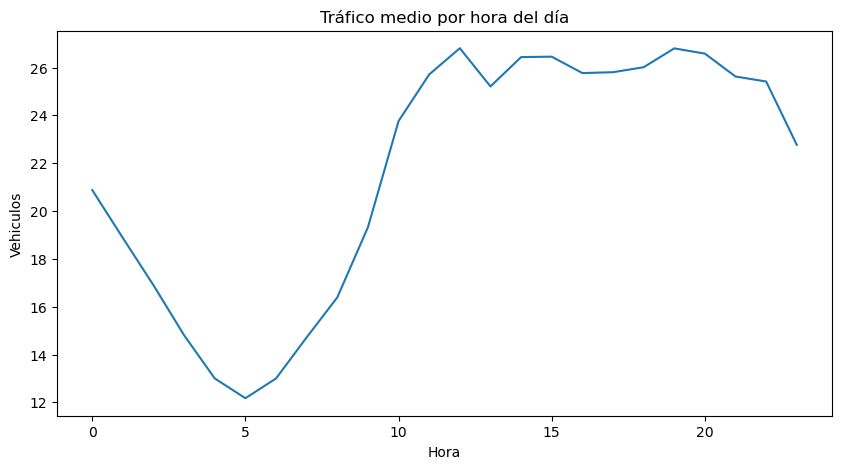

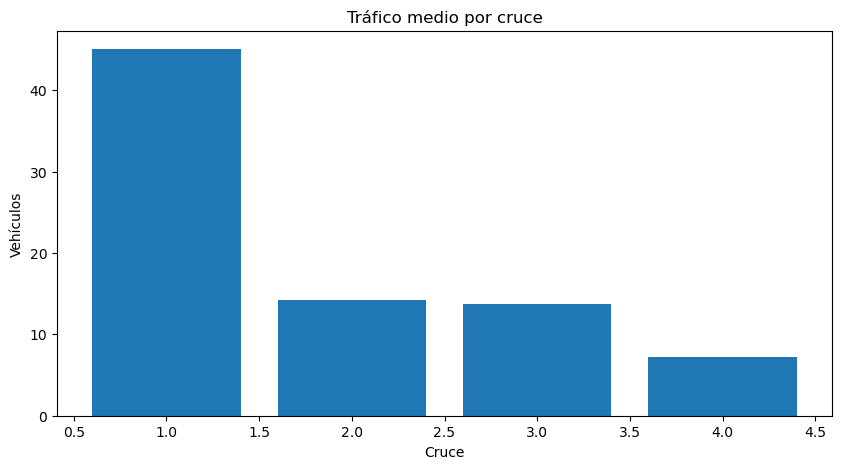

In [8]:
# Gráfica 1 - Tráfico medio por hora del día
trafico_por_hora = df.groupby('Hour')['Vehicles'].mean()

plt.figure(figsize=(10, 5))
plt.plot(trafico_por_hora.index, trafico_por_hora.values)
plt.title('Tráfico medio por hora del día')
plt.xlabel('Hora')
plt.ylabel('Vehiculos')
plt.show()

# Gráfica 2 - Tráfico medio por hora del día
df_original = pd.read_csv("traffic.csv")
trafico_por_cruce = df_original.groupby('Junction')['Vehicles'].mean()

plt.figure(figsize=(10, 5))
plt.bar(trafico_por_cruce.index, trafico_por_cruce.values)
plt.title('Tráfico medio por cruce')
plt.xlabel('Cruce')
plt.ylabel('Vehículos')
plt.show()


<h2>Separar features y target</h2>

In [9]:
'''
Vamos a separar las columnas en el eje X e Y:

    - "Eje X": columnas que el modelo usa para predecir (variables de entrada)
    - "Eje Y": columnas que queremos predecir (variable objetivo)
'''
x = df.drop(["Vehicles"], axis=1)
y = df["Vehicles"]

<h2>Split entrenamiento y test</h2>

In [10]:
'''
Normalmente para entrenar un algoritmo de Machine Learning se necesita un conjunto de datos de entrenamiento y 
otro de evaluación que nos permite medir si el modelo ha conseguido generalizar una solución razonable en datos diferentes 
de los utilizado para entrenar. Si no tenemos dos datasets, cosa muy habitual, lo normal es separar el dataset en dos, unos datos 
para entrenamiento y otros para la validación de dicho entrenamiento
'''
from sklearn.model_selection import train_test_split

'''
Entrenaremos un 80% del dataset.

    - x_train: el 80% de las filas de X, para entrenar el modelo
    - x_test: el 20% de las filas de X, para validar el modelo
    - y_train: el 80% de los valores de Vehicles, para entrenar
    - y_test: el 20% de los valores de Vehicles, para validar
'''
x_train, x_test, y_train, y_test = train_test_split(x, y, train_size = 0.8, random_state = 1234)

print(x_train.shape)
print(x_test.shape)


(36956, 7)
(9239, 7)


<h2>Comprobar si hay valores nulos o no válidos</h2>

In [11]:
'''
Algunos datasets tienen valores nulos o no válidos. Vamos a comprobar si en nuestro caso tenemos o no usando la función de pandas isna()
Este método contabiliza como TRUE aquellos elementos en cada columna que sea o None o numpy.NaN

Necesitamos el numero total de valores nulos o invalidos.
'''

x_train.isna().sum()


Hour          0
DayOfWeek     0
Month         0
IsWeekend     0
Junction_2    0
Junction_3    0
Junction_4    0
dtype: int64

<h2>Predicción de tráfico usando KNN</h2>

<h3>Método del codo para obtener la K óptima</h3>

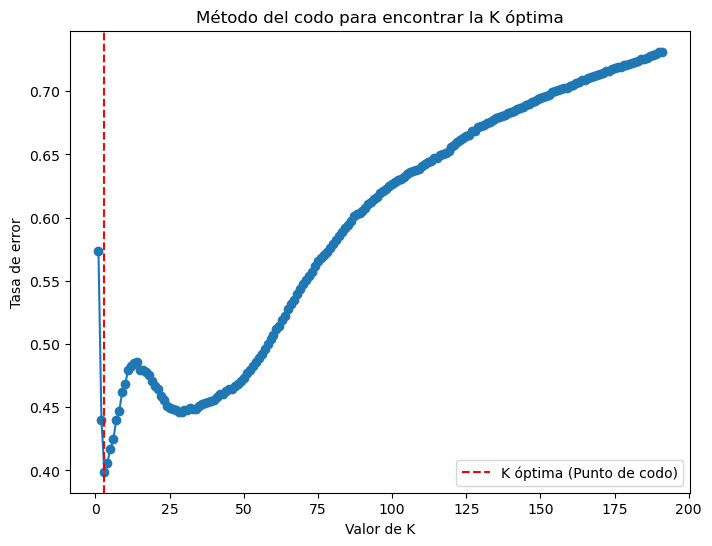

K elegida: 3


In [12]:
from sklearn.neighbors import KNeighborsRegressor as KNN

raiz = int(np.round(np.sqrt(x_train.shape[0]))) # Una K por defecto
k_optima = raiz
k_values = range(1, raiz)
error_rates = []
min_error_rate = 1.0

for k in k_values:
    knn = KNN(n_neighbors=k)
    knn.fit(x_train, y_train)
    y_pred_knn = knn.predict(x_test)
    error_rate = 1 - knn.score(x_test, y_test)
    error_rates.append(error_rate)
    if error_rate < min_error_rate: # Nos quedamos con la K que minimice el error
        min_error_rate = error_rate
        k_optima = k

plt.figure(figsize=(8, 6))
plt.plot(k_values, error_rates, marker='o')
plt.xlabel('Valor de K')
plt.ylabel('Tasa de error')
plt.title('Método del codo para encontrar la K óptima')
plt.axvline(x=3, linestyle='--', color='red', label="K óptima (Punto de codo)")
plt.legend()
plt.show()

print('K elegida: ' + str(k_optima))

<h3>Crear y entrenar el modelo KNN</h3>

In [13]:
knn = KNN(n_neighbors=k_optima)

knn.fit(x_train, y_train)

y_pred_knn = knn.predict(x_test)
y_pred_knn

array([ 9.        , 23.33333333,  7.33333333, ..., 51.66666667,
       21.33333333, 23.        ], shape=(9239,))

In [14]:
pd.DataFrame({"Predicciones" :y_pred_knn,"Valores reales": y_test})

,Predicciones,Valores reales
15123,9.000000,6
17880,23.333333,9
39889,7.333333,13
32258,9.333333,9
35426,5.666667,5
...,...,...
45347,10.666667,11
47357,4.000000,6
5592,51.666667,41
26605,21.333333,25


<h3>Calcular métricas (KNN)</h3>

In [15]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print(f'MAE: {mean_absolute_error(y_test, y_pred_knn)}')
print(f'MSE: {mean_squared_error(y_test, y_pred_knn)}')
print(f'R²: {r2_score(y_test, y_pred_knn)}')

MAE: 8.014034707940974
MSE: 138.39043427018316
R²: 0.6010144719923407


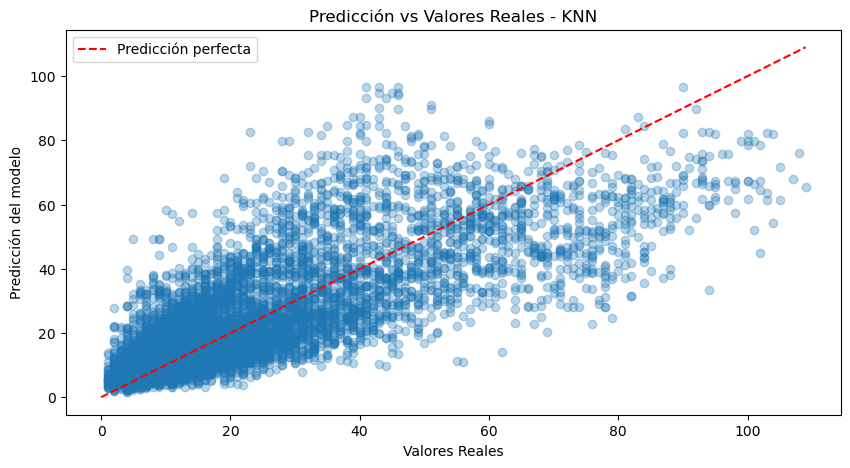

In [16]:
max_val = max(y_test.max(), y_pred_knn.max())

plt.figure(figsize=(10, 5))
plt.scatter(y_test, y_pred_knn, alpha=0.3)
plt.plot([0, max_val], [0, max_val], color='red', linestyle='--', label='Predicción perfecta')
plt.title('Predicción vs Valores Reales - KNN')
plt.xlabel('Valores Reales')
plt.ylabel('Predicción del modelo')
plt.legend()
plt.show()